### Analyse univariée des variables

Nous allons etudier notre base de données "df_imputation" après les traitements effectués

In [ ]:
from main_analysis import df_imputation

Analysons notre variable cible "taux_equipement_ve"

In [ ]:
target = "taux_equipement_ve"
print(df_imputation[target].describe())

count    35206.000000
mean         0.022886
std          0.018198
min          0.000000
25%          0.012821
50%          0.020548
75%          0.030189
max          1.000000
Name: taux_equipement_ve, dtype: float64


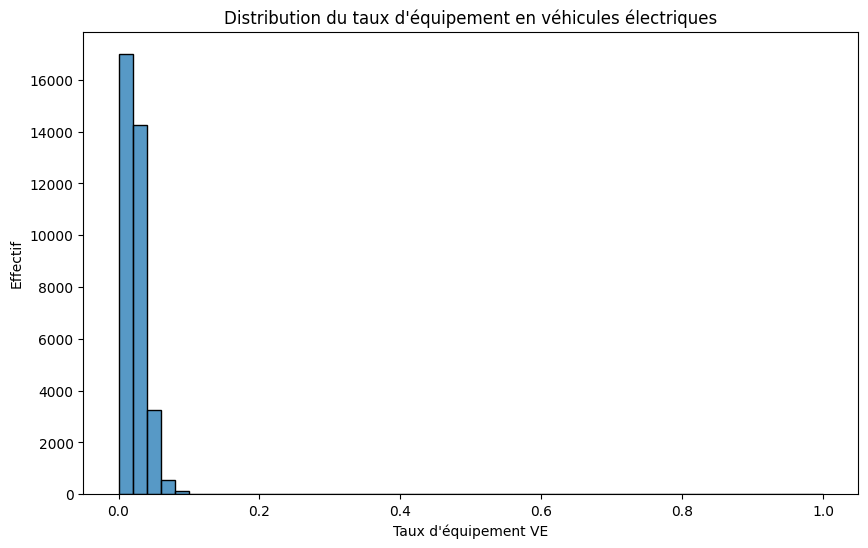

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_imputation[target], bins=50)
plt.title("Distribution du taux d'équipement en véhicules électriques")
plt.xlabel("Taux d'équipement VE")
plt.ylabel("Effectif")
plt.show()

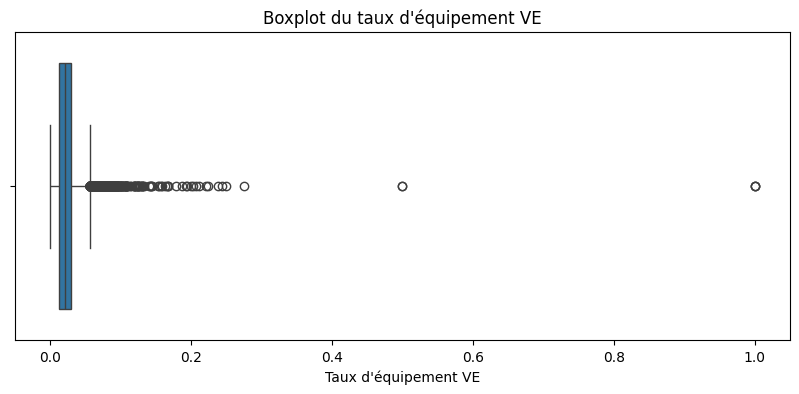

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_imputation[target])
plt.title("Boxplot du taux d'équipement VE")
plt.xlabel("Taux d'équipement VE")
plt.show()

Le boxplot met en évidence une distribution fortement asymétrique à droite du taux d’équipement en véhicules électriques.
La majorité des communes présentent des taux faibles, tandis qu’un nombre limité d’observations affiche des valeurs élevées, générant de nombreux points extrêmes.
Ces valeurs élevées ne traduisent pas nécessairement des anomalies, mais peuvent s’expliquer par des effets de petite taille de population ou par des spécificités territoriales.
Afin de limiter l’influence de ces observations sur la modélisation, une transformation logarithmique de la variable cible sera envisagée.

In [ ]:
#df_imputation["log_taux_equipement_ve"] = np.log1p(df_imputation["taux_equipement_ve"])

## Analyse des variables explicatives

In [ ]:
# Variables à exclure (identifiants / non pertinentes)
cols_to_exclude = ["CODGEO", "Libellé géographique", target]

# Variables numériques explicatives
num_cols = [
    col for col in df_imputation.select_dtypes(include=["number"]).columns
    if col not in cols_to_exclude
]

# Variables qualitatives
cat_cols = [
    col for col in df_imputation.select_dtypes(include=["object"]).columns
    if col not in ["CODGEO", "Libellé géographique"]
]

print("Variables numériques :", num_cols)
print("\nVariables qualitatives :", cat_cols)

Variables numériques : ['NB_VP', 'NB_VP_RECHARGEABLES_EL', 'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs', 'pct_type_2', 'pct_combo_ccs', 'pct_chademo', 'pct_type_ef', 'pct_gratuit', 'pct_paiement_cb', 'pct_paiement_autre', 'part_charge_rapide', 'prive', 'public', 'rapide', 'voirie', '[DISP] Médiane (€)', '[DISP] Iice de Gini', '[DISP] Nbre de ménages fiscaux', '[DISP] Nbre de personnes dans les ménages fiscaux', '[DISP] Part des revenus d’activité (%)', '[DISP] dont part des revenus des activités non salariées (%)', '[DISP] Part des revenus du patrimoine et autres revenus (%)']

Variables qualitatives : ['top_operateur']


Regardons si des variables numériques ont peu de modalités alors nous pouvons les considérer comme qualitatives :

In [ ]:
df_imputation.nunique().sort_values()

nb_operateurs                                                      34
pct_gratuit                                                        52
puissance_max                                                      91
[DISP] dont part des revenus des activités non salariées (%)      126
top_operateur                                                     157
[DISP] Part des revenus du patrimoine et autres revenus (%)       234
[DISP] Iice de Gini                                               238
pct_chademo                                                       358
rapide                                                            387
pct_paiement_autre                                                476
public                                                            483
voirie                                                            513
[DISP] Part des revenus d’activité (%)                            525
pct_type_ef                                                       532
pct_paiement_cb     

Nous gardons les variables ainsi

In [ ]:
df_var_retirees = df_imputation.drop(columns=["[DISP] Iice de Gini", "[DISP] dont part des revenus des activités non salariées (%)",
                "[DISP] Part des revenus du patrimoine et autres revenus (%)",
                "[DISP] Part des revenus d’activité (%)"])